# Customer Satisfaction Prediction (Olist) — ส่วน Order

ขอบเขตไฟล์นี้: `orders`, `order_items`, `order_payments`, `order_reviews` (products / sellers เพื่อนทำแยก — join ผ่าน `items_clean`)

**ลำดับ:** 1. Load → 2. Clean → 3. Merge + Target → 4. Filter + Feature → 5. Split → 6. พอใจ/ไม่พอใจ → 7. TODO

- **Target:** `review_score` เฉลี่ยต่อ `order_id` (regression)
- **Output:** ค่าทำนายต่อเนื่อง → แปลงด้วย threshold (`>= 4` = พอใจ, `< 4` = ไม่พอใจ)
- **ขอบเขตข้อมูล:** เฉพาะ order ที่ `delivered` แล้ว
- **Split:** แบ่ง train/test ตาม `customer_unique_id` กันลูกค้าคนเดียวกันอยู่ทั้งสองฝั่ง

In [1]:
%pip install numpy pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load data

| # | ไฟล์ | ตัวแปร | 1 แถว = |
|---|---|---|---|
| 1.1 | `olist_orders_dataset.csv` | `orders` | 1 order |
| 1.2 | `olist_order_items_dataset.csv` | `order_items` | สินค้า 1 ชิ้นใน order |
| 1.3 | `olist_order_payments_dataset.csv` | `order_payments` | การจ่ายเงิน 1 ครั้งใน order |
| 1.4 | `olist_order_reviews_dataset.csv` | `reviews` | รีวิว 1 รีวิว |
| 1.5 | `olist_customers_dataset.csv` | `customers` | ใช้แค่ map `customer_unique_id` |

In [2]:
import pandas as pd
import numpy as np

### 1.1 orders

In [3]:
order_date_cols = [
    "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date",
]
orders = pd.read_csv("olist_orders_dataset.csv", parse_dates=order_date_cols)

print(orders.shape)
orders.head(50)

(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23


### 1.2 order_items

In [4]:
order_items = pd.read_csv("olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])

print(order_items.shape)
order_items.head()

(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### 1.3 order_payments

In [5]:
order_payments = pd.read_csv("olist_order_payments_dataset.csv")

print(order_payments.shape)
order_payments.head()

(103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


### 1.4 order_reviews

In [6]:
reviews = pd.read_csv(
    "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"]
)

print(reviews.shape)
reviews.head(50)

(99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,2018-05-23 16:45:47


### 1.5 customers (ใช้แค่ map `customer_unique_id`)

In [7]:
customers = pd.read_csv("olist_customers_dataset.csv", usecols=["customer_id", "customer_unique_id"])

print(customers.shape)
customers.head()

(99441, 2)


,customer_id,customer_unique_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066


### สรุปทุกไฟล์ที่โหลด

In [8]:
raw_tables = {
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "reviews": reviews,
    "customers": customers,
}
pd.DataFrame({
    "rows": {k: v.shape[0] for k, v in raw_tables.items()},
    "cols": {k: v.shape[1] for k, v in raw_tables.items()},
    "missing_cells": {k: int(v.isnull().sum().sum()) for k, v in raw_tables.items()},
    "duplicate_rows": {k: int(v.duplicated().sum()) for k, v in raw_tables.items()},
})

,rows,cols,missing_cells,duplicate_rows
orders,99441,8,4908,0
order_items,112650,7,0,0
order_payments,103886,5,0,0
reviews,99224,7,145903,0
customers,99441,2,0,0


## 2. Clean data

`order_items` และ `order_payments` มีหลายแถวต่อ order → รวมให้เหลือ 1 แถวต่อ order ก่อน merge

`reviews` รวมเป็นคะแนนเฉลี่ยต่อ order ใน section 3

### 2.1 Clean orders

ไม่มี `order_id` ซ้ำ แต่มีวันที่ที่ขัดกันเอง:

| เคส | จำนวน | จัดการ |
|---|---|---|
| ส่งให้ขนส่ง (`carrier`) ก่อนวันสั่ง หรือ ลูกค้าได้รับก่อนส่งให้ขนส่ง | 189 | ตั้ง `carrier_date` เป็น NaT (เวลาไม่น่าเชื่อถือ) |
| ส่งให้ขนส่งก่อน approve | 1,359 | เก็บไว้ (พบบ่อยใน Olist, น่าจะเป็นเรื่องการบันทึกเวลา) |
| status = `delivered` แต่ไม่มีวันได้รับ | 8 | ถูกตัดใน section 4 |
| status = `canceled` แต่มีวันได้รับ | 6 | ถูกตัดใน section 4 |
| ส่งนานเกิน 60 วัน | 288 | เก็บไว้ (outlier จริง น่าจะมีผลกับความพอใจ) |

In [9]:
orders_clean = orders.copy()

bad_carrier = (
    (orders_clean["order_delivered_carrier_date"] < orders_clean["order_purchase_timestamp"])
    | (orders_clean["order_delivered_customer_date"] < orders_clean["order_delivered_carrier_date"])
)
orders_clean.loc[bad_carrier, "order_delivered_carrier_date"] = pd.NaT

print("order_id ซ้ำ:", orders_clean["order_id"].duplicated().sum())
print("carrier date ที่ตั้งเป็น NaT:", bad_carrier.sum())
orders_clean.isnull().sum()

order_id ซ้ำ: 0
carrier date ที่ตั้งเป็น NaT: 189


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1972
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

### 2.2 Clean order_items → รวมเป็น 1 แถวต่อ order

- ไม่มีค่าหาย ไม่มีแถวซ้ำ, `price` > 0 ทุกแถว
- `freight_value` = 0 (383 แถว) → เก็บไว้ (ส่งฟรี)
- แถวที่ `order_id + product_id + seller_id` ซ้ำกัน = ซื้อหลายชิ้น (`order_item_id` คือลำดับชิ้น) ไม่ใช่ข้อมูลซ้ำ
- `shipping_limit_date` เกิน 60 วันหลังวันสั่ง (12 แถว, บางแถวไปถึงปี 2020) → NaT
- 775 order ไม่มี items (ส่วนใหญ่ unavailable / canceled) → ถูกตัดตอนกรอง delivered
- `product_id`, `seller_id` เก็บไว้ใน `items_clean` สำหรับ join กับงานของเพื่อน

In [10]:
items_clean = order_items.merge(
    orders_clean[["order_id", "order_purchase_timestamp"]], on="order_id", how="left"
)
bad_limit = (items_clean["shipping_limit_date"] - items_clean["order_purchase_timestamp"]).dt.days > 60
items_clean.loc[bad_limit, "shipping_limit_date"] = pd.NaT
items_clean = items_clean.drop(columns="order_purchase_timestamp")

items_agg = items_clean.groupby("order_id", as_index=False).agg(
    n_items=("order_item_id", "count"),
    n_products=("product_id", "nunique"),
    n_sellers=("seller_id", "nunique"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    shipping_limit_date=("shipping_limit_date", "max"),
)
items_agg["freight_ratio"] = items_agg["total_freight"] / (items_agg["total_price"] + items_agg["total_freight"])

print("shipping_limit_date ที่ตั้งเป็น NaT:", bad_limit.sum())
print(items_agg.shape, "order_id ซ้ำ:", items_agg["order_id"].duplicated().sum())
items_agg.describe()

shipping_limit_date ที่ตั้งเป็น NaT: 12
(98666, 8) order_id ซ้ำ: 0


,n_items,n_products,n_sellers,total_price,total_freight,shipping_limit_date,freight_ratio
count,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000,98656,98666.000000
mean,1.141731,1.038098,1.013622,137.754076,22.823562,2018-01-07 12:28:16.563169,0.208804
min,1.000000,1.000000,1.000000,0.850000,0.000000,2016-09-19 00:15:34,0.000000
25%,1.000000,1.000000,1.000000,45.900000,13.850000,2017-09-20 02:55:33,0.116502
50%,1.000000,1.000000,1.000000,86.900000,17.170000,2018-01-26 13:52:23.500000,0.183256
75%,1.000000,1.000000,1.000000,149.900000,24.040000,2018-05-10 15:10:36.750000,0.275463
max,21.000000,8.000000,5.000000,13440.000000,1794.960000,2018-09-18 21:10:15,0.955451
std,0.538452,0.226456,0.122297,210.645145,21.650909,NaN,0.125749


### 2.3 Clean order_payments → รวมเป็น 1 แถวต่อ order

- ไม่มีค่าหาย ไม่มีแถวซ้ำ
- `payment_installments` = 0 (2 แถว, credit_card) → 1
- `payment_type` = `not_defined` (3 แถว) เป็น order ที่ canceled ทั้งหมด → ถูกตัดตอนกรอง delivered
- `payment_value` = 0 (9 แถว) เป็น voucher / not_defined → เก็บไว้
- 1 order (delivered) ไม่มีข้อมูล payment → ค่าจะเป็น NaN หลัง merge
- ยอดจ่ายต่างจากราคาสินค้า+ค่าส่งเกิน 1 BRL แค่ 249 order (น่าจะเป็นดอกเบี้ยผ่อน) → เก็บไว้
- `main_payment_type` = ช่องทางที่จ่ายเงินมากที่สุดใน order นั้น

In [11]:
payments_clean = order_payments.copy()
payments_clean.loc[payments_clean["payment_installments"] == 0, "payment_installments"] = 1

main_payment_type = (
    payments_clean.sort_values("payment_value", ascending=False)
    .drop_duplicates("order_id")[["order_id", "payment_type"]]
    .rename(columns={"payment_type": "main_payment_type"})
)

payments_agg = payments_clean.groupby("order_id", as_index=False).agg(
    total_payment=("payment_value", "sum"),
    n_payments=("payment_sequential", "count"),
    max_installments=("payment_installments", "max"),
    used_voucher=("payment_type", lambda s: int((s == "voucher").any())),
)
payments_agg = payments_agg.merge(main_payment_type, on="order_id", how="left")

print(payments_agg.shape, "order_id ซ้ำ:", payments_agg["order_id"].duplicated().sum())
payments_agg["main_payment_type"].value_counts()

(99440, 6) order_id ซ้ำ: 0


main_payment_type
credit_card    74975
boleto         19784
voucher         3151
debit_card      1527
not_defined        3
Name: count, dtype: int64

## 3. Merge ทุกไฟล์เป็น 1 แถวต่อ order + Target

- `reviews` บาง order มีหลายรีวิว (551 แถว) → เฉลี่ยคะแนนให้เหลือ 1 order ต่อ 1 แถว = **target**
- merge: `order_scores` ← `orders_clean` ← `customers` ← `items_agg` ← `payments_agg` (ทุกตัว join ด้วย `order_id`, ยกเว้น customers ใช้ `customer_id`)

In [12]:
order_scores = (
    reviews.groupby("order_id", as_index=False)
           .agg(review_score=("review_score", "mean"),
                n_reviews=("review_id", "count"))
)

df = (
    order_scores
    .merge(orders_clean, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(items_agg, on="order_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
)

print(df.shape, "order_id ซ้ำ:", df["order_id"].duplicated().sum())
df["order_status"].value_counts()

(98673, 23) order_id ซ้ำ: 0


order_status
delivered      95832
shipped         1032
canceled         605
unavailable      595
invoiced         309
processing       295
created            3
approved           2
Name: count, dtype: int64

## 4. กรองเฉพาะ delivered + feature การจัดส่ง

order ที่ไม่ใช่ `delivered` (canceled, unavailable, shipped ฯลฯ ~2,800 order) มีคะแนนเฉลี่ย ~1.75 และไม่มีวันส่งถึง → ตัดออก

- `delivery_days` = วันที่ได้รับ − วันที่สั่ง
- `late_days` = วันที่ได้รับ − วันที่คาดว่าจะได้รับ (บวก = ส่งช้า)
- `is_late` = ส่งช้ากว่ากำหนดหรือไม่

⚠️ ห้ามใช้ `review_comment_*` / `review_*_date` เป็น feature (data leakage)

In [13]:
df = (
    df[df["order_status"] == "delivered"]
    .dropna(subset=["order_delivered_customer_date"])
    .reset_index(drop=True)
)

df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["late_days"]     = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days
df["is_late"]       = (df["late_days"] > 0).astype(int)

print(df.shape)
df[["review_score", "delivery_days", "late_days", "is_late"]].describe()

(95824, 26)


,review_score,delivery_days,late_days,is_late
count,95824.000000,95824.000000,95824.000000,95824.000000
mean,4.156158,12.052273,-11.913070,0.066591
std,1.283615,9.466046,10.111737,0.249313
min,1.000000,0.000000,-147.000000,0.000000
25%,4.000000,6.000000,-17.000000,0.000000
50%,5.000000,10.000000,-12.000000,0.000000
75%,5.000000,15.000000,-7.000000,0.000000
max,5.000000,208.000000,188.000000,1.000000


### 4.1 Export CSV (order ที่ clean + merge แล้ว)

1 แถว = 1 order (delivered) รวมข้อมูลจาก orders, order_items, order_payments, order_reviews + `customer_unique_id`

In [14]:
df.to_csv("order_clean_merged.csv", index=False, encoding="utf-8-sig")
print("saved order_clean_merged.csv", df.shape)

saved order_clean_merged.csv (95824, 26)


## 5. Train/test split ตาม customer_unique_id

ลูกค้า ~2,950 คนมีมากกว่า 1 order → ใช้ `GroupShuffleSplit` กันลูกค้าคนเดียวกันอยู่ทั้ง train และ test

In [15]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["customer_unique_id"]))
train, test = df.iloc[train_idx], df.iloc[test_idx]

overlap = set(train["customer_unique_id"]) & set(test["customer_unique_id"])
print(train.shape, test.shape, "ลูกค้าซ้ำระหว่าง train/test:", len(overlap))

(76642, 26) (19182, 26) ลูกค้าซ้ำระหว่าง train/test: 0


## 6. แปลงคะแนนเป็น พอใจ / ไม่พอใจ

ใช้กับทั้ง `y_test` และค่าที่โมเดลทำนาย หลังเทรนเสร็จ

In [16]:
def to_satisfaction(score, threshold=4.0):
    return np.where(score >= threshold, "พอใจ", "ไม่พอใจ")

pd.Series(to_satisfaction(df["review_score"])).value_counts(normalize=True)

พอใจ       0.789145
ไม่พอใจ    0.210855
Name: proportion, dtype: float64

## 7. TODO: รวมงานเพื่อน + เทรนโมเดล

- feature จาก products / sellers (เพื่อนทำ) → join ผ่าน `items_clean` (`product_id`, `seller_id`) แล้วรวมเป็นระดับ order ก่อน merge เข้า `df`
- เทรน regression บน `train`

หลังเทรนเสร็จ ประเมินผลด้วย (ดู recall ของ "ไม่พอใจ" ด้วย เพราะข้อมูลเอียงไปทาง "พอใจ"):

```python
from sklearn.metrics import classification_report

y_pred = np.clip(model.predict(X_test), 1, 5)
print(classification_report(to_satisfaction(y_test), to_satisfaction(y_pred)))
```

In [17]:
clean_merged_df = pd.read_csv("order_clean_merged.csv")

print(clean_merged_df.shape)



(95824, 26)


In [18]:
clean_merged_df

,order_id,review_score,n_reviews,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,shipping_limit_date,freight_ratio,total_payment,n_payments,max_installments,used_voucher,main_payment_type,delivery_days,late_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,...,2017-09-19 09:45:35,0.184098,72.19,1.0,2.0,0.0,credit_card,7,-9,0
1,00018f77f2f0320c557190d7a144bdd3,4.0,1,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,...,2017-05-03 11:05:13,0.076704,259.83,1.0,3.0,0.0,credit_card,16,-3,0
2,000229ec398224ef6ca0657da4fc703e,5.0,1,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,...,2018-01-18 14:48:30,0.082400,216.87,1.0,5.0,0.0,credit_card,7,-14,0
3,00024acbcdf0a6daa1e931b038114c75,4.0,1,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,...,2018-08-15 10:10:18,0.496121,25.78,1.0,2.0,0.0,credit_card,6,-6,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,...,2017-02-13 13:57:51,0.083196,218.04,1.0,3.0,0.0,credit_card,25,-16,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95819,fffc94f6ce00a00581880bf54a75a037,5.0,1,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,...,2018-05-02 04:11:01,0.126412,343.40,1.0,1.0,0.0,boleto,17,-8,0
95820,fffcd46ef2263f404302a634eb57f7eb,5.0,1,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01,...,2018-07-20 04:31:48,0.094508,386.53,1.0,1.0,0.0,boleto,9,-9,0
95821,fffce4705a9662cd70adb13d4a31832d,5.0,1,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10,...,2017-10-30 17:14:25,0.145058,116.85,1.0,3.0,0.0,credit_card,4,-13,0
95822,fffe18544ffabc95dfada21779c9644f,5.0,1,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25,...,2017-08-21 00:04:32,0.134755,64.71,1.0,3.0,0.0,credit_card,1,-9,0


## 8. Plot จาก `clean_merged_df`

In [19]:
import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e8e7e3", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "font.family": ["Tahoma", "DejaVu Sans"],  # Tahoma แสดงภาษาไทยได้บน Windows
})

def label_bars(ax, bars, fmt="{:.2f}"):
    for b in bars:
        ax.annotate(fmt.format(b.get_height()), (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom",
                    fontsize=9, color=INK_2)

plot_df = clean_merged_df.copy()
plot_df["order_purchase_timestamp"] = pd.to_datetime(plot_df["order_purchase_timestamp"])
plot_df["satisfied"] = np.where(plot_df["review_score"] >= 4, "พอใจ", "ไม่พอใจ")

### 8.1 Target: review_score และ พอใจ / ไม่พอใจ

คะแนนเอียงไปทาง 5 มาก → ไม่พอใจแค่ ~21% (imbalanced)

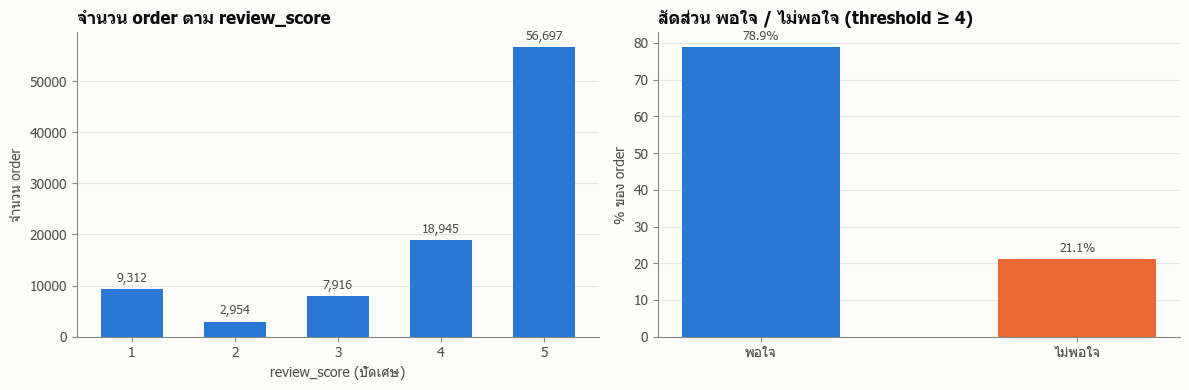

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

score_counts = plot_df["review_score"].round().value_counts().sort_index()
bars = axes[0].bar(score_counts.index.astype(int).astype(str), score_counts.values, color=BLUE, width=0.6)
label_bars(axes[0], bars, "{:,.0f}")
axes[0].set_title("จำนวน order ตาม review_score")
axes[0].set_xlabel("review_score (ปัดเศษ)")
axes[0].set_ylabel("จำนวน order")

sat_share = plot_df["satisfied"].value_counts(normalize=True).reindex(["พอใจ", "ไม่พอใจ"]) * 100
bars = axes[1].bar(sat_share.index, sat_share.values, color=[BLUE, ORANGE], width=0.5)
label_bars(axes[1], bars, "{:.1f}%")
axes[1].set_title("สัดส่วน พอใจ / ไม่พอใจ (threshold ≥ 4)")
axes[1].set_ylabel("% ของ order")

fig.tight_layout()
plt.show()

### 8.2 การจัดส่ง vs คะแนน

feature ที่แรงที่สุด: ส่งช้าเมื่อไหร่คะแนนตกจาก ~4.3 เหลือ ~2.3 และตกหนักทันทีที่เลยกำหนดส่ง

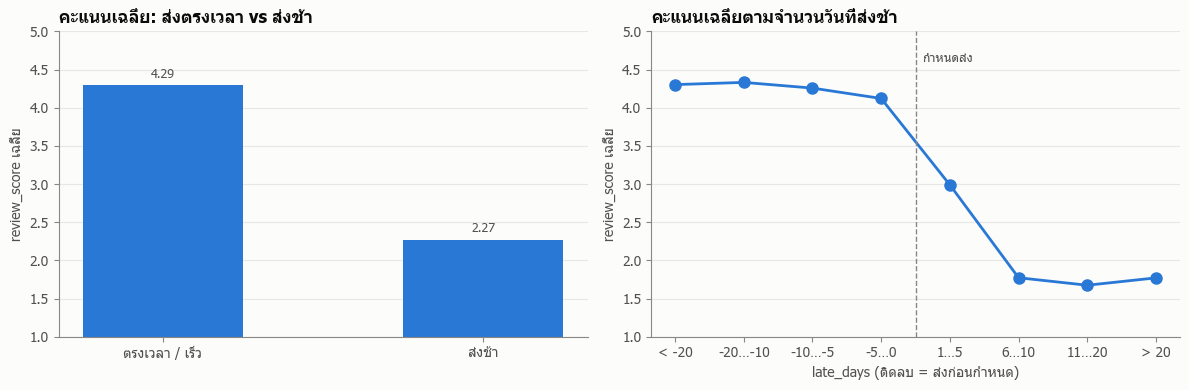

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

late_score = plot_df.groupby("is_late")["review_score"].mean().rename({0: "ตรงเวลา / เร็ว", 1: "ส่งช้า"})
bars = axes[0].bar(late_score.index, late_score.values, color=BLUE, width=0.5)
label_bars(axes[0], bars)
axes[0].set_ylim(1, 5)
axes[0].set_title("คะแนนเฉลี่ย: ส่งตรงเวลา vs ส่งช้า")
axes[0].set_ylabel("review_score เฉลี่ย")

bins = [-np.inf, -20, -10, -5, 0, 5, 10, 20, np.inf]
labels = ["< -20", "-20…-10", "-10…-5", "-5…0", "1…5", "6…10", "11…20", "> 20"]
plot_df["late_bin"] = pd.cut(plot_df["late_days"], bins=bins, labels=labels)
late_curve = plot_df.groupby("late_bin", observed=True)["review_score"].mean()
axes[1].plot(late_curve.index.astype(str), late_curve.values, color=BLUE, linewidth=2, marker="o", markersize=8)
axes[1].axvline(3.5, color=MUTED, linewidth=1, linestyle="--")
axes[1].annotate("กำหนดส่ง", (3.5, 4.6), xytext=(5, 0), textcoords="offset points", color=INK_2, fontsize=9)
axes[1].set_ylim(1, 5)
axes[1].set_title("คะแนนเฉลี่ยตามจำนวนวันที่ส่งช้า")
axes[1].set_xlabel("late_days (ติดลบ = ส่งก่อนกำหนด)")
axes[1].set_ylabel("review_score เฉลี่ย")

fig.tight_layout()
plt.show()

### 8.3 จำนวนสินค้า / วิธีจ่ายเงิน vs คะแนน

- ยิ่งสินค้าเยอะใน order คะแนนยิ่งต่ำ (4.21 → 3.36)
- วิธีจ่ายเงินแทบไม่ต่างกัน (4.13–4.24) → น่าจะเป็น feature ที่อ่อน

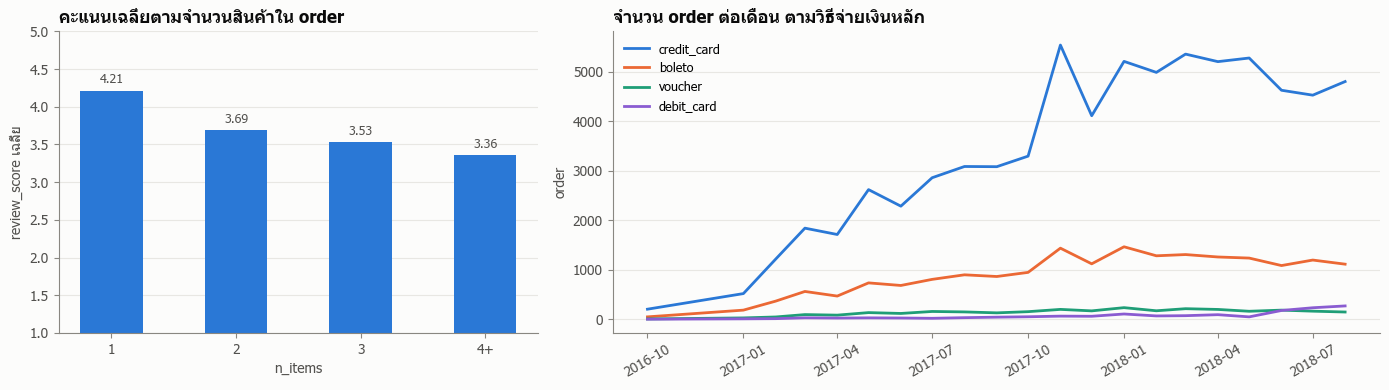

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 1.6]})

plot_df["n_items_group"] = plot_df["n_items"].clip(upper=4).astype(int).astype(str).replace("4", "4+")
items_score = plot_df.groupby("n_items_group")["review_score"].mean()
bars = axes[0].bar(items_score.index, items_score.values, color=BLUE, width=0.5)
label_bars(axes[0], bars)
axes[0].set_ylim(1, 5)
axes[0].set_title("คะแนนเฉลี่ยตามจำนวนสินค้าใน order")
axes[0].set_xlabel("n_items")
axes[0].set_ylabel("review_score เฉลี่ย")

# จำนวน order ต่อเดือนแยกตามวิธีจ่ายเงิน (ตัดเดือนที่มี order รวม < 100 ออก เหมือน 8.5)
pay_monthly = (
    plot_df.groupby([pd.Grouper(key="order_purchase_timestamp", freq="MS"), "main_payment_type"])
    .size()
    .unstack(fill_value=0)
)
pay_monthly = pay_monthly[pay_monthly.sum(axis=1) >= 100]
pay_colors = {"credit_card": BLUE, "boleto": ORANGE, "voucher": "#1f9e77", "debit_card": "#8a5cd1"}
for ptype, color in pay_colors.items():
    axes[1].plot(pay_monthly.index, pay_monthly[ptype], color=color, linewidth=2, label=ptype)
axes[1].set_title("จำนวน order ต่อเดือน ตามวิธีจ่ายเงินหลัก")
axes[1].set_ylabel("order")
axes[1].legend(frameon=False, fontsize=9)
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

### 8.4 การกระจายของ feature ตัวเลข

`delivery_days` และ `total_price` เบ้ขวามาก (ราคาใช้ log scale) → ถ้าใช้ linear model ควร log-transform

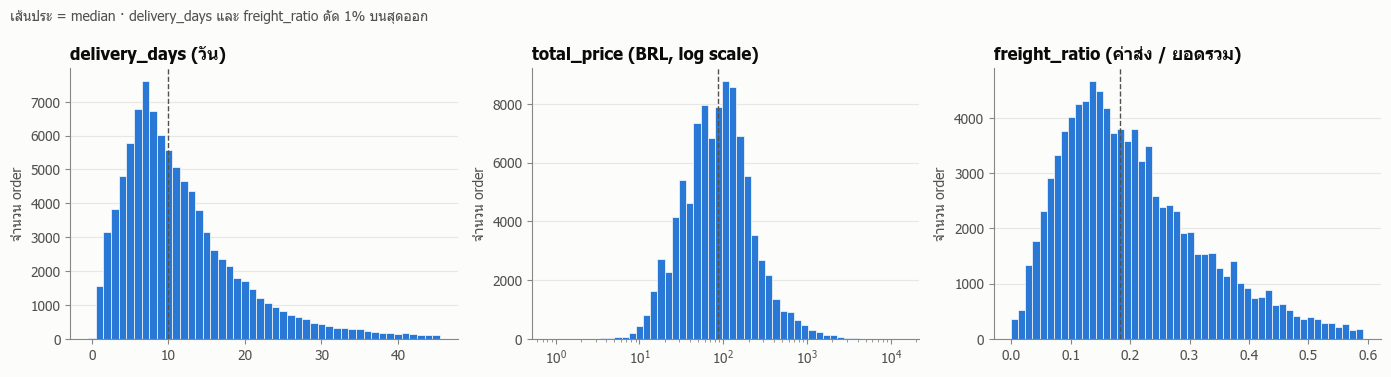

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

days = plot_df["delivery_days"].dropna()
days = days[days <= days.quantile(0.99)]
axes[0].hist(days, bins=np.arange(0, days.max() + 2) - 0.5, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[0].axvline(days.median(), color=INK_2, linewidth=1, linestyle="--")
axes[0].set_title("delivery_days (วัน)")

price = plot_df["total_price"].dropna()
axes[1].hist(price, bins=np.logspace(np.log10(price.min()), np.log10(price.max()), 50),
             color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[1].set_xscale("log")
axes[1].axvline(price.median(), color=INK_2, linewidth=1, linestyle="--")
axes[1].set_title("total_price (BRL, log scale)")

ratio = plot_df["freight_ratio"].dropna()
ratio = ratio[ratio <= ratio.quantile(0.99)]
axes[2].hist(ratio, bins=50, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[2].axvline(ratio.median(), color=INK_2, linewidth=1, linestyle="--")
axes[2].set_title("freight_ratio (ค่าส่ง / ยอดรวม)")

for ax in axes:
    ax.set_ylabel("จำนวน order")
fig.suptitle("เส้นประ = median · delivery_days และ freight_ratio ตัด 1% บนสุดออก",
             x=0.01, ha="left", fontsize=10, color=INK_2)
fig.tight_layout()
plt.show()

### 8.5 แนวโน้มรายเดือน

% ไม่พอใจพุ่งช่วง ก.พ.–มี.ค. 2018 (~30%) ซึ่งเป็นช่วงที่ order เยอะ → น่าเช็กว่าช่วงนั้นส่งช้าเยอะด้วยไหม (ตัดเดือนที่มี order < 100 ออก)

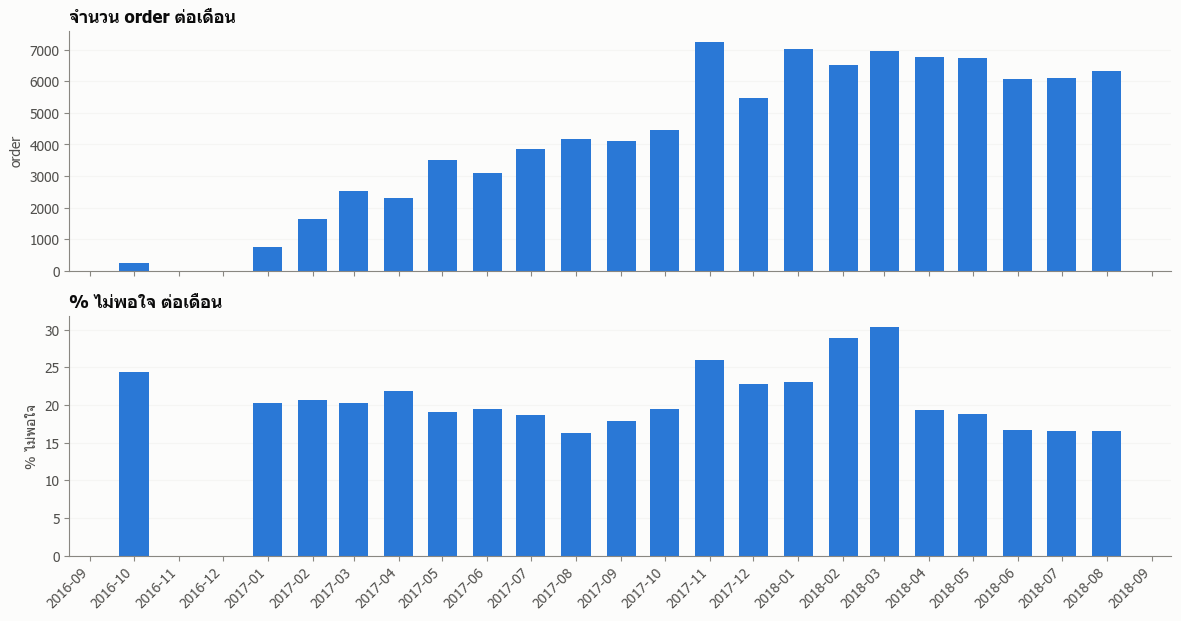

In [25]:
import matplotlib.dates as mdates
monthly = (
    plot_df.set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(orders=("order_id", "count"),
         unsatisfied=("satisfied", lambda s: (s == "ไม่พอใจ").mean() * 100))
)
monthly = monthly[monthly["orders"] >= 100]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].bar(monthly.index, monthly["orders"], width=20, color=BLUE)
axes[0].set_title("จำนวน order ต่อเดือน")
axes[0].set_ylabel("order")

axes[1].bar(monthly.index, monthly["unsatisfied"], width=20, color=BLUE)
axes[1].set_title("% ไม่พอใจ ต่อเดือน")
axes[1].set_ylabel("% ไม่พอใจ")
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.tight_layout()
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
plt.show()
